# S04.09 — DBSCAN
## Módulo 3, Tema 1: Introducción a Machine Learning — Subtema 4

**Técnica:** DBSCAN (clustering basado en densidad, `sklearn.cluster.DBSCAN`)
**Tarea:** aprendizaje **no supervisado** — segmentación por densidad y detección de atípicos
**Dataset:** Sintético v2 — 30,000 pólizas
**Variables de clustering:** `CLUSTERING_FEATURES` (sin targets ni identificadores)

---

## 1. Contexto actuarial

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) define un **cluster** como una
región **densa** de puntos separada por regiones de baja densidad. A diferencia de K-Means:

- **No requiere fijar el número de clusters** de antemano: emerge de la densidad.
- **Identifica observaciones atípicas** explícitamente como **ruido** (etiqueta `-1`).
- **Puede recuperar formas no convexas** cuando se cumplen las condiciones de densidad
  (a diferencia de K-Means, que tiende a grupos esféricos).

### 1.1 Uso en seguros (prudente)

- Detección de **perfiles de emisión atípicos** (ruido) para revisión.
- Los atípicos son **candidatos a revisión**, **no** evidencia de fraude ni de riesgo elevado por
  sí solos.

### 1.2 Regla de datos

El ajuste usa solo `CLUSTERING_FEATURES`; se excluyen `id_poliza_sin` y todos los targets.

> *Fuentes principales:* ESL Cap. 14 §14.3 (densidad); scikit-learn User Guide (`DBSCAN`); Murphy (2022) Cap. 21.

## 2. Fundamento matemático

### 2.1 Vecindad, núcleo, frontera y ruido

Dado un radio $\varepsilon$ y un mínimo `minPts` (`min_samples`):

$$N_\varepsilon(p)=\{q: d(p,q)\le \varepsilon\}$$

- **Punto núcleo:** $|N_\varepsilon(p)|\ge \text{minPts}$ (la vecindad **incluye a $p$**).
- **Punto frontera:** está dentro de $\varepsilon$ de un núcleo, pero tiene menos de `minPts` vecinos.
- **Ruido (`-1`):** ni núcleo ni frontera → observación atípica.

Los clusters se forman conectando núcleos **alcanzables por densidad**.

### 2.2 Elección de eps: k-distance plot

Con `NearestNeighbors(n_neighbors=min_samples).kneighbors(X)`, la **primera columna es el propio
punto** (distancia 0). La **última columna** es el radio necesario para reunir `min_samples` puntos
**incluyendo $p$** — equivale a la distancia al **4º vecino distinto** cuando `min_samples=5`. Se
ordena esa distancia ascendentemente; el **codo** de la curva solo **sugiere** un $\varepsilon$
candidato (no marca una frontera cierta).

In [1]:
import sys
from pathlib import Path

_candidates = [Path.cwd() / "", Path.cwd().parent / "", Path.cwd().parent.parent / ""]
_src_path = next((p for p in _candidates if (p / "simulate_portfolio_v2.py").exists()), None)
if _src_path is None:
    raise FileNotFoundError(
        "No se encontró simulate_portfolio_v2.py. "
        "Ejecutar desde la raíz del proyecto o desde content/notebooks/."
    )
sys.path.insert(0, str(_src_path))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulate_portfolio_v2 import (
    simulate_auto_insurance_portfolio_v2,
    FEATURE_COLUMNS, TARGET_COLUMNS, CLUSTERING_FEATURES,
)

SEED = 20260618
N    = 30_000
NAVY = "#003B5C"; GOLD = "#C8A33A"; RED = "#C0392B"; GREEN = "#2E7D44"
CLUSTER_COLORS = ["#003B5C", "#C8A33A", "#2E7D44", "#C0392B", "#6A5ACD", "#008B8B", "#B8860B"]

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

df = simulate_auto_insurance_portfolio_v2(n_policies=N, seed=SEED)
print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

# ── Regla de seguridad: el clustering NUNCA usa targets ni identificadores ────
assert set(CLUSTERING_FEATURES).isdisjoint(set(TARGET_COLUMNS)), \
    "CLUSTERING_FEATURES no debe intersecar TARGET_COLUMNS"
assert "id_poliza_sin" not in CLUSTERING_FEATURES, "id_poliza_sin no es feature de clustering"
assert set(CLUSTERING_FEATURES).issubset(set(FEATURE_COLUMNS)), \
    "CLUSTERING_FEATURES debe ser subconjunto de FEATURE_COLUMNS"
print("Variables de clustering (canonicas):", CLUSTERING_FEATURES)
print("Excluidas del ajuste: id_poliza_sin y todos los targets:", TARGET_COLUMNS)
print("Verificacion CLUSTERING_FEATURES ∩ TARGET_COLUMNS = vacio: OK")

# en k mean se veia la distancia entre la variable y el centroide
# aqui se mide la densidad (que se vaya relacionando, similar a un municipio, la densidad de poblacion en un determinado lugar determina los municipios)
# todo lo que este alrededor de un punto con un radio epsilon
# ruido pueden ser los valores atipicos


Dataset cargado: 30,000 filas x 23 columnas
Variables de clustering (canonicas): ['edad', 'suma_asegurada', 'num_renovaciones', 'antiguedad_vehiculo', 'kilometraje']
Excluidas del ajuste: id_poliza_sin y todos los targets: ['prima_neta', 'n_siniestros', 'monto_siniestro', 'siniestro_alto', 'status_poliza']
Verificacion CLUSTERING_FEATURES ∩ TARGET_COLUMNS = vacio: OK


## 3. Preparación: submuestra, escalamiento y PCA (decisión de modelación)

- **Submuestra determinística** de 10,000 pólizas (`sample`, `random_state=SEED`) por el costo del
  cálculo de vecindades; reproducible.
- **StandardScaler:** `eps` es sensible a la escala.
- **PCA a 2 componentes antes de DBSCAN:** decisión de modelación explícita (facilita la elección
  de `eps` y la visualización; cambia el espacio de distancias respecto a las 4 dimensiones).

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

DBSCAN_SUB = 10_000
MIN_SAMPLES = 11
# se estandarizan datos
sub_db = df.sample(n=DBSCAN_SUB, random_state=SEED)
X_db_scaled = StandardScaler().fit_transform(sub_db[CLUSTERING_FEATURES].to_numpy(dtype=float))
pca_db = PCA(n_components=2, random_state=SEED).fit(X_db_scaled)
X_db = pca_db.transform(X_db_scaled)
db_var = pca_db.explained_variance_ratio_
print(f"Submuestra DBSCAN: {X_db.shape[0]:,} obs. (determinista, random_state=SEED)")
print(f"PC1+PC2 explican {(db_var[0]+db_var[1])*100:.0f}% de la varianza en la submuestra")
#se busca que gran parte de los datos expliquen la varianza de la muestra


Submuestra DBSCAN: 10,000 obs. (determinista, random_state=SEED)
PC1+PC2 explican 49% de la varianza en la submuestra


## 4. Elección de eps con el k-distance plot

`kneighbors(X)` sobre los mismos puntos incluye a cada punto consigo mismo (distancia 0) en la
primera columna. Tomamos la **última columna** (radio para reunir `min_samples` puntos incluyendo
el punto; con `min_samples=5`, el **4º vecino distinto**), la ordenamos y buscamos el codo, que
**sugiere** un `eps` candidato.

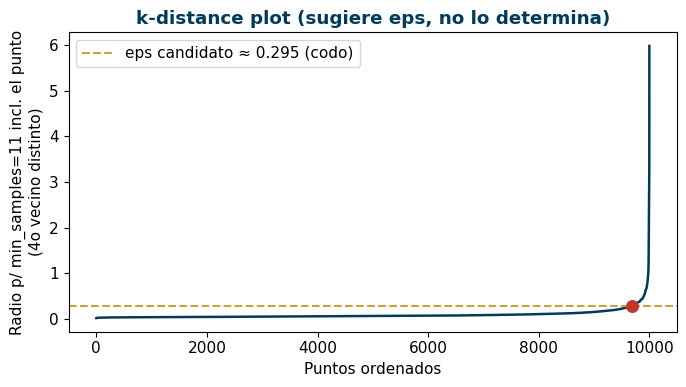

eps candidato en el codo: 0.295  |  min_samples=11
kneighbors incluye el propio punto (dist 0); la ultima columna es el 4o vecino distinto.


In [9]:
def knee_index(y: np.ndarray) -> int:
    """Indice del punto de maxima distancia a la cuerda (determinista).

    Sobre una curva monotona ordenada, devuelve el indice del punto mas alejado de la
    recta que une el primer y el ultimo punto. Es una HEURISTICA del codo: solo sugiere
    un valor candidato, no una curvatura exacta ni una frontera cierta.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    x = np.arange(n, dtype=float)
    x1, x2, y1, y2 = x[0], x[-1], y[0], y[-1]
    num = np.abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1)
    den = np.hypot(y2 - y1, x2 - x1)
    d = num / (den if den > 0 else 1.0)
    return int(np.argmax(d))


from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_db)
dist_nn, _ = nn.kneighbors(X_db)      # col 0 = el propio punto (distancia 0)
kth = np.sort(dist_nn[:, -1])         # ultima col = radio p/ min_samples incl. p (4o vecino distinto)
eps_idx = knee_index(kth)
eps_db = float(round(kth[eps_idx], 3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(len(kth)), kth, color=NAVY, lw=1.8)
ax.axhline(eps_db, color=GOLD, ls="--", label=f"eps candidato ≈ {eps_db} (codo)")
ax.scatter([eps_idx], [kth[eps_idx]], s=70, color=RED, zorder=5)
ax.set_xlabel("Puntos ordenados")
ax.set_ylabel(f"Radio p/ min_samples={MIN_SAMPLES} incl. el punto\n(4o vecino distinto)")
ax.set_title("k-distance plot (sugiere eps, no lo determina)", color=NAVY, fontweight="bold"); ax.legend()
plt.tight_layout(); plt.show()
print(f"eps candidato en el codo: {eps_db}  |  min_samples={MIN_SAMPLES}")
print("kneighbors incluye el propio punto (dist 0); la ultima columna es el 4o vecino distinto.")
# en donde cambia la pendiente es donde se encuentra el epsilon óptimo


## 5. Ajuste de DBSCAN y resultados

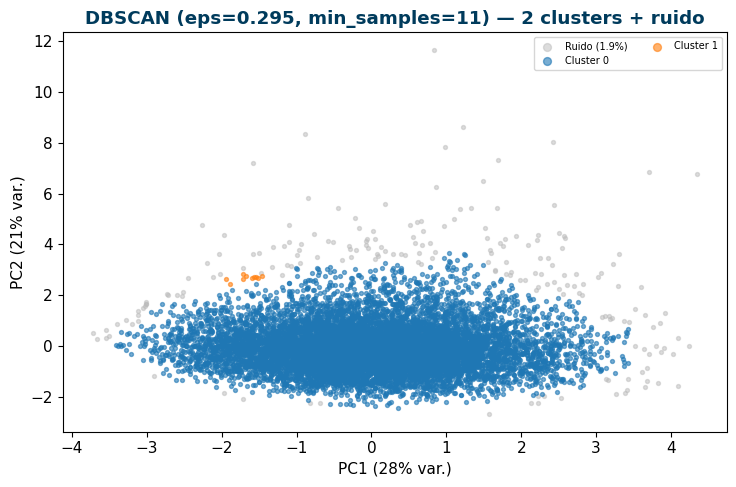

DBSCAN clusters=2  ruido=1.9%  silhouette(sin ruido)=0.4282
Cluster dominante concentra 99.9% de los puntos no-ruido.
Interpretacion honesta: un cluster dominante + fragmentos pequenos y silhouette bajo indican
separacion DEBIL en esta configuracion (eps/min_samples/PCA). No es una segmentacion concluyente.


In [10]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

db = DBSCAN(eps=eps_db, min_samples=MIN_SAMPLES).fit(X_db)
db_labels = db.labels_
db_n_clusters = int(len(set(db_labels)) - (1 if -1 in db_labels else 0))
db_noise = float(np.mean(db_labels == -1))

mask = db_labels != -1
if db_n_clusters >= 2 and mask.sum() > db_n_clusters:
    db_sil = float(silhouette_score(X_db[mask], db_labels[mask],
                                    sample_size=min(5000, int(mask.sum())), random_state=SEED))
else:
    db_sil = float("nan")

# Tamanos de cluster (para interpretacion honesta)
db_cluster_sizes = pd.Series(db_labels[mask]).value_counts().sort_values(ascending=False)
dom_frac = float(db_cluster_sizes.iloc[0] / mask.sum()) if mask.sum() else float("nan")

# Colores distintos para todos los clusters (evita leyenda enganosa con colores repetidos)
cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(7.5, 5))
noise = db_labels == -1
ax.scatter(X_db[noise, 0], X_db[noise, 1], s=8, color="#BBBBBB", alpha=0.5, label=f"Ruido ({db_noise*100:.1f}%)")
for ci, c in enumerate(sorted(set(db_labels) - {-1})):
    m = db_labels == c
    ax.scatter(X_db[m, 0], X_db[m, 1], s=8, alpha=0.6, color=cmap(ci % 10), label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({db_var[0]*100:.0f}% var.)"); ax.set_ylabel(f"PC2 ({db_var[1]*100:.0f}% var.)")
ax.set_title(f"DBSCAN (eps={eps_db}, min_samples={MIN_SAMPLES}) — {db_n_clusters} clusters + ruido",
             color=NAVY, fontweight="bold")
ax.legend(markerscale=2, fontsize=7, ncol=2, loc="upper right"); plt.tight_layout(); plt.show()

print(f"DBSCAN clusters={db_n_clusters}  ruido={db_noise*100:.1f}%  silhouette(sin ruido)={db_sil:.4f}")
print(f"Cluster dominante concentra {dom_frac*100:.1f}% de los puntos no-ruido.")
print("Interpretacion honesta: un cluster dominante + fragmentos pequenos y silhouette bajo indican")
print("separacion DEBIL en esta configuracion (eps/min_samples/PCA). No es una segmentacion concluyente.")
# se ve que acsi todo esta en el cluster 0

## 6. Análisis de sensibilidad a eps y min_samples

No existe un par de parámetros "correcto" universal. La tabla muestra cómo cambian el número de
clusters y el % de ruido al variar `eps` y `min_samples`.

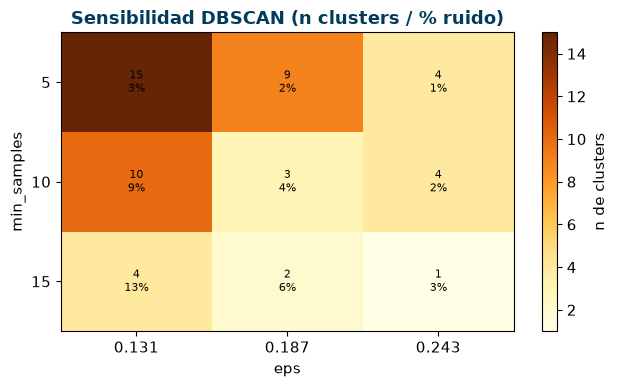

Al aumentar eps, el % de ruido NO aumenta (tiende a disminuir).
El numero de clusters NO es necesariamente monotono en eps: pueden aparecer grupos desde el
ruido y luego fusionarse. Ej.: en alguna fila el conteo pasa de 3 a 4 clusters al subir eps.


In [5]:
eps_grid = [round(eps_db * f, 3) for f in (0.7, 1.0, 1.3)]
ms_grid = [5, 10, 15]
sens_nclus = np.zeros((len(ms_grid), len(eps_grid)), dtype=int)
sens_noise = np.zeros((len(ms_grid), len(eps_grid)), dtype=float)
for i, ms in enumerate(ms_grid):
    for j, ep in enumerate(eps_grid):
        lab = DBSCAN(eps=ep, min_samples=ms).fit_predict(X_db)
        sens_nclus[i, j] = len(set(lab)) - (1 if -1 in lab else 0)
        sens_noise[i, j] = float(np.mean(lab == -1))

fig, ax = plt.subplots(figsize=(6.5, 4))
im = ax.imshow(sens_nclus, cmap="YlOrBr", aspect="auto")
ax.set_xticks(range(len(eps_grid))); ax.set_xticklabels(eps_grid)
ax.set_yticks(range(len(ms_grid))); ax.set_yticklabels(ms_grid)
ax.set_xlabel("eps"); ax.set_ylabel("min_samples")
for i in range(len(ms_grid)):
    for j in range(len(eps_grid)):
        ax.text(j, i, f"{sens_nclus[i,j]}\n{sens_noise[i,j]*100:.0f}%", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, label="n de clusters")
ax.set_title("Sensibilidad DBSCAN (n clusters / % ruido)", color=NAVY, fontweight="bold")
plt.tight_layout(); plt.show()
print("Al aumentar eps, el % de ruido NO aumenta (tiende a disminuir).")
print("El numero de clusters NO es necesariamente monotono en eps: pueden aparecer grupos desde el")
print("ruido y luego fusionarse. Ej.: en alguna fila el conteo pasa de 3 a 4 clusters al subir eps.")


## 7. Interpretación de observaciones atípicas (análisis posterior)

El **ruido** son pólizas con perfil poco frecuente en el espacio proyectado. Como **análisis
posterior** (los targets no formaron los clusters), comparamos ruido vs. no-ruido en algunos
targets. Esto **no** convierte al ruido en fraude ni en riesgo elevado: es un punto de partida
para revisión.

In [6]:
post = sub_db[TARGET_COLUMNS].copy()
post["es_ruido"] = (db_labels == -1)
resumen = post.groupby("es_ruido").agg(
    prima_neta_media=("prima_neta", "mean"),
    tasa_siniestro=("siniestro_alto", "mean"),
    n=("prima_neta", "size"),
).round(3)
print("ANALISIS POSTERIOR — ruido vs no-ruido (los targets NO formaron los clusters):")
print(resumen.to_string())
print()
print("Los atipicos son candidatos a revision, no una etiqueta de fraude ni de riesgo por si solos.")


ANALISIS POSTERIOR — ruido vs no-ruido (los targets NO formaron los clusters):
          prima_neta_media  tasa_siniestro     n
es_ruido                                        
False            10000.322           0.289  9837
True             20869.931           0.374   163

Los atipicos son candidatos a revision, no una etiqueta de fraude ni de riesgo por si solos.


## 8. Interpretación actuarial y limitaciones

**Uso actuarial (prudente):**
- Detección de pólizas con perfiles atípicos para revisión (sin llamarlas fraude).
- Segmentación cuando los grupos no son esféricos ni de igual tamaño.
- En esta configuración la separación es débil (un cluster dominante, silhouette bajo): tratar el
  resultado como exploratorio, no concluyente.

**Limitaciones:**
- Muy sensible a `eps` y `min_samples`; requieren criterio y reporte.
- Dificultad con clusters de densidades muy distintas.
- En alta dimensión las distancias se concentran (maldición de la dimensión).
- La **PCA previa cambia el espacio de distancias**: los resultados son condicionales a ese
  preprocesamiento.
- Escalabilidad: el costo depende de la dimensión, `eps`, la estructura de vecinos (índices
  espaciales) y la memoria disponible; no es universalmente barato.
- "Ruido" es una etiqueta técnica, no un juicio de negocio.

## 9. Ejercicio propuesto

1. **Sin PCA:** aplica DBSCAN sobre las 4 variables escaladas (sin reducir a 2D). Recalcula el
   k-distance plot y `eps`. ¿Cambian el número de clusters y el % de ruido? ¿Por qué?
2. **Otro min_samples:** repite con `min_samples=10`. Ajusta `eps` con el nuevo k-distance plot.
3. **Comparación con K-Means:** proyecta ambas particiones en PCA 2D. ¿DBSCAN recupera formas que
   K-Means no? Mide la concordancia con ARI **solo sobre los puntos no-ruido** (mismas
   observaciones), reportando el % excluido.

---

### Referencias bibliográficas

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Cap. 14 §14.3.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. Cap. 21.
- scikit-learn Developers. *User Guide* v1.9.0. `DBSCAN`, `NearestNeighbors`, `StandardScaler`, `PCA`, `silhouette_score`.
- Wüthrich, M. V., & Buser, C. *Data Analytics for Non-Life Insurance Pricing*. Swiss Finance Institute Research Paper No. 16-68. SSRN: https://ssrn.com/abstract=2870308 (consultado 2026-06-17). Cap. 2 (contexto general de ML en seguros de no-vida).